# Kmean and db scan clustering algo and implementation

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans #partitions an unlabeled dataset into distinct groups (clusters) based on feature similarity
from sklearn.preprocessing import StandardScaler

#Use the make_blobs tool in Python to build fake datasets.
#It creates groups of data points shaped like round clouds.
#These clouds have a Gaussian distribution (data forms a bell curve around the center)

In [19]:
X, y_true = make_blobs(n_samples=500, centers=3, n_features=2,cluster_std=0.60,random_state=42)

In [20]:
df = pd.DataFrame(X,columns=["Feature_1","Feature_2"])

In [21]:
df

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


# Kmean Clustering

In [22]:
scaler = StandardScaler()
X_scaler = scaler.fit_transform(df)

In [23]:
inertia = []
K_range = range(1,11)

In [24]:
for k in K_range:
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaler)
    inertia.append(kmeans.inertia_)

In [25]:
inertia

[1000.0,
 297.8954141051723,
 11.575484723104982,
 9.752067977356841,
 8.257175272446284,
 6.9175773204168,
 6.334755391595291,
 5.70417717790143,
 5.0602341335320755,
 4.762361898130395]

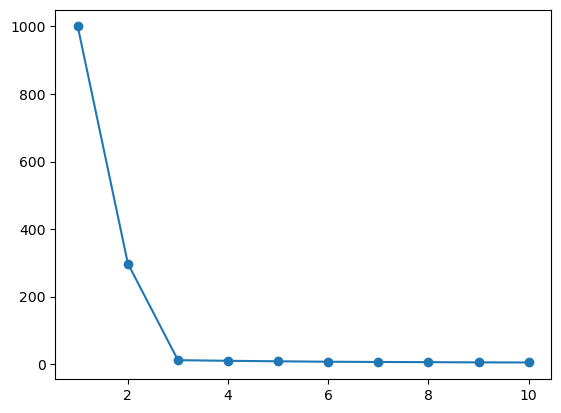

In [26]:
plt.plot(K_range,inertia,marker = "o")

In [45]:
kmeans_final = KMeans(n_clusters=3,random_state=42)

In [46]:
cluster_labels = kmeans_final.fit_predict(X_scaler)

In [47]:
df["cluster"] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

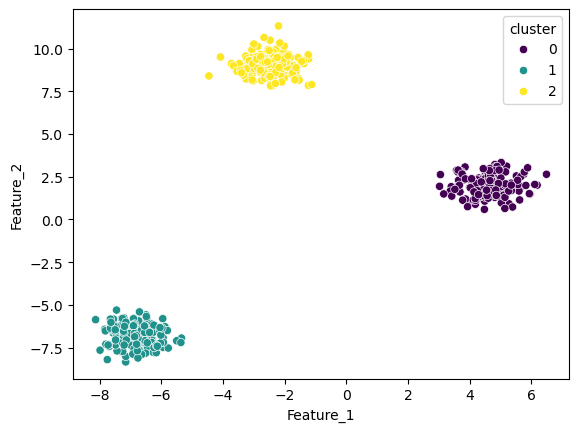

In [48]:
sns.scatterplot(x=df["Feature_1"],y=df["Feature_2"],hue=df["cluster"],palette="viridis")

# Db scan algo implementation

In [49]:
from sklearn.datasets import make_moons

In [50]:
X, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

In [51]:
from sklearn.cluster import KMeans,DBSCAN

In [52]:
df = pd.DataFrame(X,columns=["Feature_1","Feature_2"])

In [53]:
df

,Feature_1,Feature_2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185
...,...,...
495,0.239754,0.985462
496,0.072145,0.184834
497,0.590273,-0.365577
498,1.619465,-0.283658


In [54]:
scaler = StandardScaler()
X_scaler = scaler.fit_transform(df)

# Kmeans

In [56]:
cluster_labels = kmeans_final.fit_predict(X_scaler)
df["cluster"] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

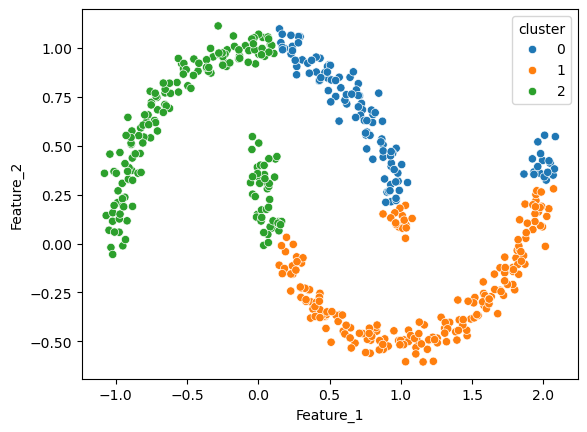

In [57]:
sns.scatterplot(x=df["Feature_1"],y=df["Feature_2"],hue=df["cluster"],palette="tab10")

In [58]:
dbscan = DBSCAN(eps=0.3,min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaler)

In [59]:
df["cluster"] = dbscan_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

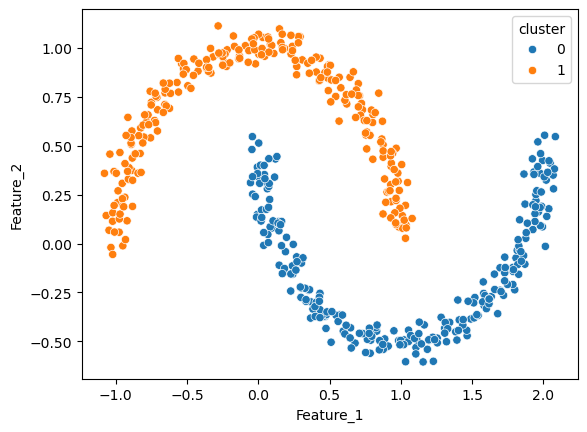

In [60]:
sns.scatterplot(x=df["Feature_1"],y=df["Feature_2"],hue=df["cluster"],palette="tab10")